In [53]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
from util import *

In [54]:
tex_fonts = {
    #source: https://jwalton.info/Embed-Publication-Matplotlib-Latex/
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": "serif",
    # Use 10pt font in plots, to match 10pt font in document
    #"axes.labelsize": 10,
    "font.size": 10,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 8,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    'text.latex.preamble': r"\usepackage{amsmath}"
}

In [55]:
year = 2020

# Data

In [56]:
data = gpd.read_file(data_folder + '{}_spatial_raw_master.geojson'.format(year))
data.set_index('geography code', inplace=True)

In [99]:
data.shape, data.dropna().shape

((33755, 106), (29130, 106))

In [58]:
data['o_total_quantity_per_capita'] = data['o_total_quantity_per_capita'].apply(np.log)

In [59]:
data[data['geometry'].isna()]

,LSOA21NM,centroid_x,centroid_y,c_percent asian,c_percent black,c_percent mixed,c_percent white,c_percent christian,c_percent jewish,c_percent no religion,...,e_snow_and_ice,o_diabetes_quantity_per_capita,o_opioids_quantity_per_capita,o_OME_per_capita,o_total_quantity_per_capita,o_asthma_quantity_per_capita,o_hypertension_quantity_per_capita,o_depression_quantity_per_capita,o_anxiety_quantity_per_capita,geometry
geography code,,,,,,,,,,,,,,,,,,,,,


# LSOAs

In [39]:
# fn = 'LSOA_(Dec_2021)_Boundaries_Generalised_Clipped_EW_(BGC)'
# fp = auxiliary_data_folder + '/lsoas_2021/{}/{}.shp'.format(fn, fn)
# lsoas_2021 = gpd.read_file(fp).rename(columns={'LSOA21CD':'geography code'})

# merge data and lsoas 

In [40]:
# df = data.join(lsoas_2021[['geography code']].set_index('geography code'), on='geography code', how='right')

In [41]:
# df.shape

# plot maps

In [60]:
# gdf = gpd.GeoDataFrame(data, geometry='geometry')
gdf = data.copy()

In [61]:
# gdf.set_index('geography code', inplace=True)

In [62]:
gdf.head(10)

,LSOA21NM,centroid_x,centroid_y,c_percent asian,c_percent black,c_percent mixed,c_percent white,c_percent christian,c_percent jewish,c_percent no religion,...,e_snow_and_ice,o_diabetes_quantity_per_capita,o_opioids_quantity_per_capita,o_OME_per_capita,o_total_quantity_per_capita,o_asthma_quantity_per_capita,o_hypertension_quantity_per_capita,o_depression_quantity_per_capita,o_anxiety_quantity_per_capita,geometry
geography code,,,,,,,,,,,,,,,,,,,,,
E01000001,City of London 001A,532151.194178,181615.201393,0.107191,0.007463,0.037992,0.801221,0.345763,0.019661,0.483390,...,0.092108,0.834958,0.129840,1.134302,2.626636,0.139674,1.047404,0.262661,0.195967,"POLYGON ((532105.312 182010.574, 532162.491 18..."
E01000002,City of London 001B,532443.686041,181645.724884,0.130592,0.007937,0.043290,0.782107,0.338150,0.025289,0.491329,...,0.108474,0.957987,0.276066,2.587085,3.002415,0.203468,1.341916,0.378103,0.275255,"POLYGON ((532634.497 181926.016, 532619.141 18..."
E01000003,City of London 001C,532207.014825,182030.129598,0.094913,0.034739,0.062655,0.741315,0.340360,0.026658,0.479851,...,0.088695,1.532698,0.592661,5.072608,3.607429,0.361956,2.189897,0.738527,0.530043,"POLYGON ((532135.138 182198.131, 532158.250 18..."
E01000005,City of London 001E,533618.348516,181157.354255,0.321526,0.108084,0.071753,0.385104,0.367514,0.012704,0.221416,...,0.072893,0.918772,0.250619,2.218236,3.205100,0.359229,1.447732,0.827553,0.481856,"POLYGON ((533808.018 180767.774, 533649.037 18..."
E01000006,Barking and Dagenham 016A,544934.369716,184297.546524,0.479675,0.108401,0.037940,0.327913,0.371614,0.000542,0.070423,...,0.032890,33.986967,4.982723,191.202486,6.301225,5.155322,36.456869,5.625583,4.351535,"POLYGON ((545122.049 184314.931, 545271.849 18..."
E01000007,Barking and Dagenham 015A,544140.628715,184437.591450,0.319683,0.284928,0.062973,0.288025,0.381493,0.000344,0.125559,...,0.050718,34.714072,4.215028,70.518171,6.195690,5.308563,35.291601,5.980129,4.181289,"POLYGON ((544180.347 184700.582, 544317.196 18..."
E01000008,Barking and Dagenham 015B,543631.449397,184385.251864,0.256125,0.398664,0.048441,0.250000,0.471604,0.000000,0.100223,...,0.034572,38.969994,4.341368,63.082523,6.249992,6.020124,39.211323,6.753980,4.603642,"MULTIPOLYGON (((543741.001 184566.000, 543806...."
E01000009,Barking and Dagenham 016B,544602.674652,184457.531467,0.489751,0.111911,0.029363,0.303601,0.305987,0.001109,0.092572,...,0.030667,28.144607,3.664536,91.464983,6.076471,4.176030,29.334370,4.583790,3.433592,"POLYGON ((544499.837 184704.366, 544630.292 18..."
E01000011,Barking and Dagenham 016C,544382.715979,184738.624036,0.548122,0.100939,0.024061,0.283451,0.330394,0.000588,0.054674,...,0.034769,41.903619,4.625035,79.526818,6.412213,6.011479,41.737055,6.495747,4.843271,"POLYGON ((544523.402 184789.039, 544667.055 18..."


In [63]:
gdf.shape

(33755, 106)

In [105]:
4625/33755

0.13701673826099836

In [64]:
gdf[gdf['o_diabetes_quantity_per_capita'].isna()]['geometry']

geography code
E01013079    POLYGON ((534928.793 427161.609, 535059.522 42...
E01013082    POLYGON ((531953.144 430981.672, 532894.344 42...
E01013083    POLYGON ((534129.044 428335.478, 534487.882 42...
E01013086    POLYGON ((532331.289 422826.240, 532347.846 42...
E01014383    POLYGON ((352329.812 164021.095, 352382.688 16...
                                   ...                        
E01035758    POLYGON ((440023.734 188362.550, 440025.000 18...
E01035759    POLYGON ((448931.938 193306.859, 449093.219 19...
E01035760    POLYGON ((450708.409 190217.086, 450944.308 19...
E01035761    POLYGON ((448999.655 189423.097, 448975.672 18...
E01035762    POLYGON ((446534.981 225101.393, 446996.281 22...
Name: geometry, Length: 1956, dtype: geometry

In [65]:
gdf[gdf['e_total_aerosol_optical_depth_at_550nm_surface'].isna()]

,LSOA21NM,centroid_x,centroid_y,c_percent asian,c_percent black,c_percent mixed,c_percent white,c_percent christian,c_percent jewish,c_percent no religion,...,e_snow_and_ice,o_diabetes_quantity_per_capita,o_opioids_quantity_per_capita,o_OME_per_capita,o_total_quantity_per_capita,o_asthma_quantity_per_capita,o_hypertension_quantity_per_capita,o_depression_quantity_per_capita,o_anxiety_quantity_per_capita,geometry
geography code,,,,,,,,,,,,,,,,,,,,,
E01000007,Barking and Dagenham 015A,544140.628715,184437.591450,0.319683,0.284928,0.062973,0.288025,0.381493,0.000344,0.125559,...,0.050718,34.714072,4.215028,70.518171,6.195690,5.308563,35.291601,5.980129,4.181289,"POLYGON ((544180.347 184700.582, 544317.196 18..."
E01000009,Barking and Dagenham 016B,544602.674652,184457.531467,0.489751,0.111911,0.029363,0.303601,0.305987,0.001109,0.092572,...,0.030667,28.144607,3.664536,91.464983,6.076471,4.176030,29.334370,4.583790,3.433592,"POLYGON ((544499.837 184704.366, 544630.292 18..."
E01000018,Barking and Dagenham 009D,549322.151534,185265.403035,0.130068,0.186374,0.042793,0.624437,0.498311,0.001126,0.273086,...,0.029875,37.394486,9.484960,82.077130,6.578205,7.763867,56.823122,10.986685,7.642767,"POLYGON ((549333.827 185536.234, 549351.304 18..."
E01000036,Barking and Dagenham 010B,550432.459743,185260.956387,0.278610,0.199591,0.019074,0.471390,0.517687,0.000680,0.152381,...,0.054901,60.185383,13.679222,114.072679,6.847306,11.735563,88.376604,14.745849,9.762478,"POLYGON ((549719.797 185534.661, 549924.367 18..."
E01000038,Barking and Dagenham 003C,550720.767282,187157.610899,0.166873,0.111663,0.040943,0.647022,0.516708,0.001856,0.249381,...,0.031589,58.860020,14.021153,154.200899,7.014782,10.464995,90.911866,18.740464,11.642072,"POLYGON ((550739.318 187373.774, 550978.754 18..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
E01035706,Tower Hamlets 036E,537870.179827,179234.903068,0.426026,0.060418,0.065066,0.402014,0.294026,0.003103,0.301784,...,0.039928,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((537996.000 179400.000, 537970.444 17..."
E01035715,Westminster 007H,525905.310144,182146.657722,0.109150,0.031340,0.047190,0.729467,0.392729,0.035997,0.289777,...,0.030985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((525927.000 182304.000, 526008.772 18..."
E01035717,Westminster 014H,525370.527897,181485.018281,0.080824,0.088220,0.079239,0.678817,0.402111,0.021108,0.361478,...,0.027339,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"POLYGON ((525582.183 181638.547, 525565.190 18..."


In [66]:
gdf[gdf['e_surface_thermal_radiation_downwards_sum'].isna()]['geometry']

geography code
E01006738    POLYGON ((340574.000 384009.000, 340660.143 38...
E01006986    POLYGON ((329099.577 408371.765, 329135.715 40...
E01006989    POLYGON ((328277.950 408149.187, 328269.000 40...
E01006990    POLYGON ((329123.140 407734.513, 329137.779 40...
E01006991    POLYGON ((328308.885 407173.153, 328343.165 40...
                                   ...                        
E01035367    POLYGON ((340215.886 377155.951, 340249.639 37...
E01035368    POLYGON ((339854.282 377082.937, 339909.488 37...
E01035631    POLYGON ((431767.072 580975.889, 431769.034 58...
E01035632    POLYGON ((432374.150 580586.250, 432441.559 58...
E01035635    POLYGON ((428983.396 580917.682, 429135.838 58...
Name: geometry, Length: 1479, dtype: geometry

# test v2

In [46]:
# def plot_variable(gdf, variable, variable_name):

#     if variable.startswith('e'):
#         colormap = 'spring'
#     elif variable.startswith('o'):
#         colormap = 'cool'
#     elif variable.startswith('c'):
#         colormap = 'viridis'
#     else:
#         colormap = 'coolwarm'


#     # Plotting the GeoPandas DataFrame
#     ax = gdf.plot(column=variable, legend=True, figsize=(15, 10), cmap=colormap);

#     # Remove the axes
#     plt.axis('off')

#     # Customize the legend font size
#     # Get the color bar object
#     cax = plt.gcf().axes[-1]

#     # Customize the color bar font size
#     cax.tick_params(labelsize=18)

#     # Remove the axes
#     plt.title(variable_name, fontsize=25);

In [95]:
def plot_variable_v2(gdf, variable, variable_name):

    if variable.startswith('e'):
        colormap = colors.LinearSegmentedColormap.from_list('', ['#ffffff', '#c27ba0'])
    elif variable.startswith('o'):
        colormap = colors.LinearSegmentedColormap.from_list('', ['#ffffff', '#6d9eeb'])
    elif variable.startswith('c'):
        colormap = colors.LinearSegmentedColormap.from_list('', ['#ffffff', '#008080'])
    else:
        colormap = 'coolwarm'

    # Parameters to display missing data in black
    missing_data_color = {
        'color': 'black',
        # 'color':'#808080',
        # 'edgecolor': 'black',
        # 'hatch': '///',  # this is optional, if you'd like a hatch pattern for missing data
        'label': 'Missing Data'
    }

    # Plotting the GeoPandas DataFrame
    ax = gdf.plot(column=variable, legend=True, figsize=(15, 10), cmap=colormap, missing_kwds=missing_data_color)

    # Remove the axes
    plt.axis('off')

    # Customize the legend font size
    # Get the color bar object
    cax = plt.gcf().axes[-1]

    # Customize the color bar font size
    cax.tick_params(labelsize=33)

    # Title
    plt.title(variable_name, fontsize=44)

In [68]:
def plot_variable(gdf, variable, variable_name):

    if variable.startswith('e'):
        colormap = colors.LinearSegmentedColormap.from_list('', ['#ffffff', '#c27ba0'])
    elif variable.startswith('o'):
        colormap = colors.LinearSegmentedColormap.from_list('', ['#ffffff', '#6d9eeb'])
    elif variable.startswith('c'):
        colormap = colors.LinearSegmentedColormap.from_list('', ['#ffffff', '#008080'])
    else:
        colormap = 'coolwarm'

    # Plotting the GeoPandas DataFrame
    ax = gdf.plot(column=variable, legend=True, figsize=(15, 10), cmap=colormap)

    # Remove the axes
    plt.axis('off')

    # Customize the legend font size
    # Get the color bar object
    cax = plt.gcf().axes[-1]

    # Customize the color bar font size
    cax.tick_params(labelsize=33)

    # Remove the axes
    plt.title(variable_name, fontsize=44)


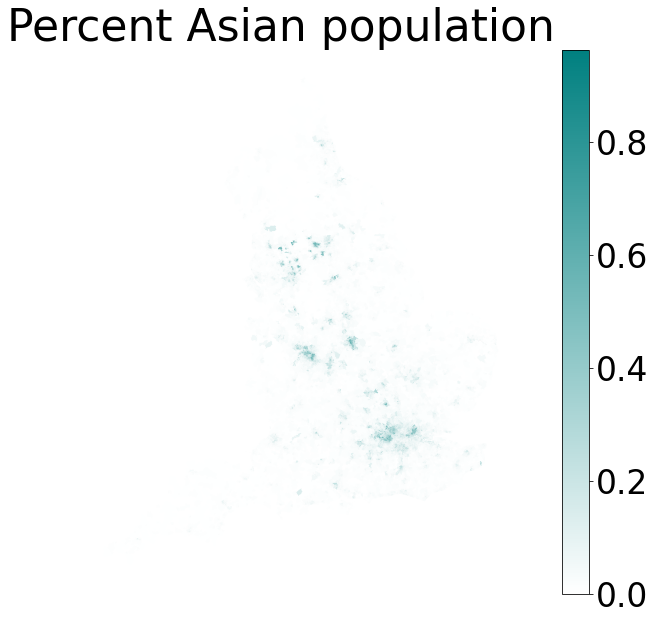

In [69]:
variable = 'c_percent asian'
variable_name = 'Percent Asian population'
plot_variable_v2(gdf, variable, variable_name)

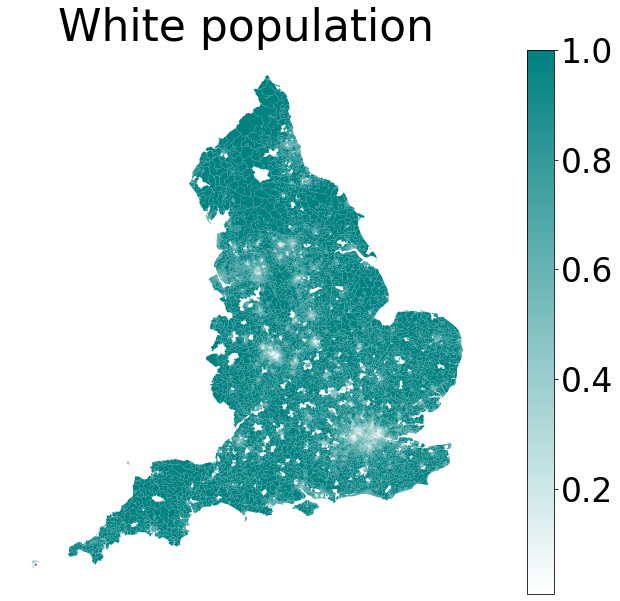

In [12]:
variable = 'c_percent white'
variable_name = 'White population'
plot_variable_v2(gdf, variable, variable_name)

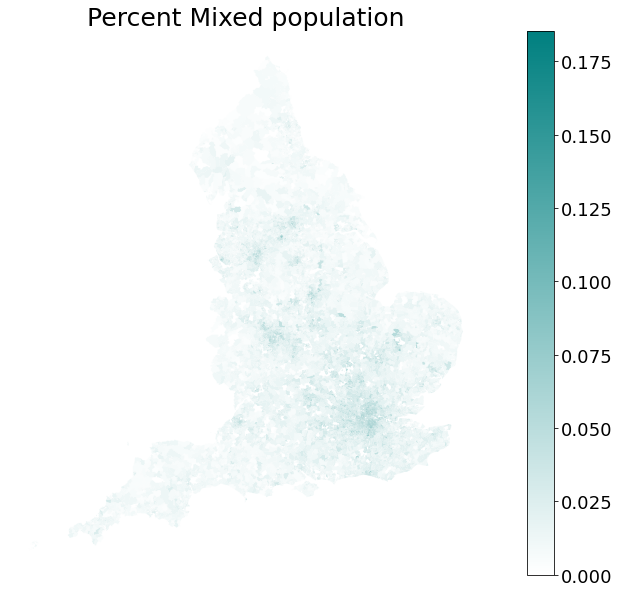

In [11]:
variable = 'c_percent mixed'
variable_name = 'Percent Mixed population'
plot_variable(gdf, variable, variable_name)

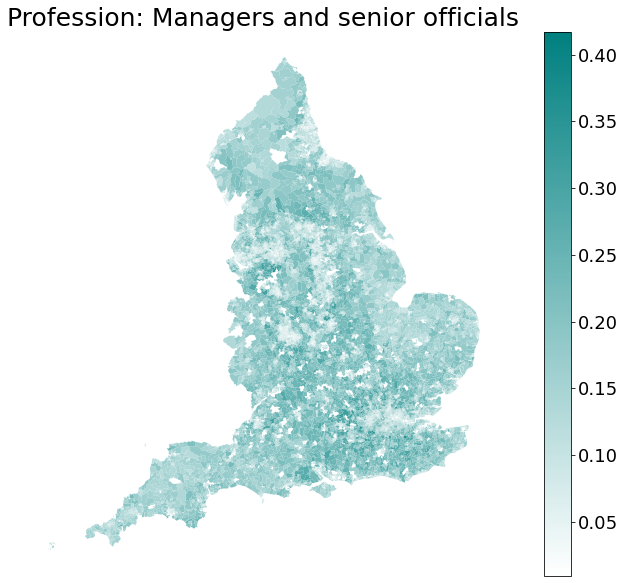

In [12]:
variable = 'c_percent 1. Managers directors and senior officials'
variable_name = 'Profession: Managers and senior officials'
plot_variable(gdf, variable, variable_name)


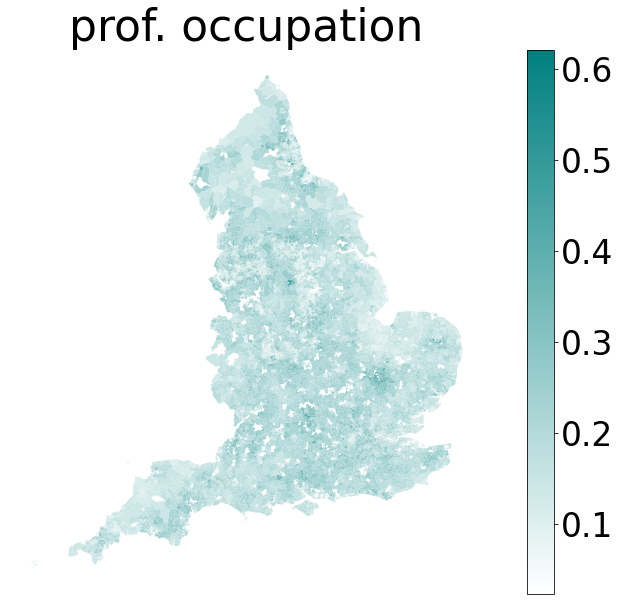

In [81]:
variable = 'c_percent 2. Professional occupations'
variable_name = 'prof. occupation'
plot_variable(gdf, variable, variable_name)


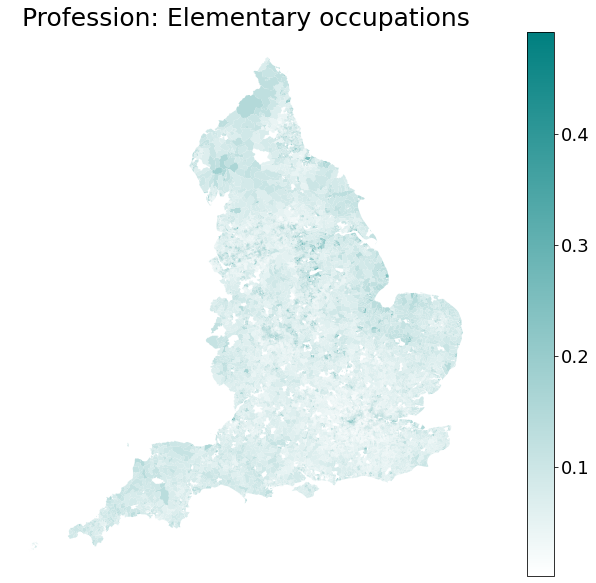

In [14]:
variable = 'c_percent 9. Elementary occupations'
variable_name = 'Profession: Elementary occupations'
plot_variable(gdf, variable, variable_name)


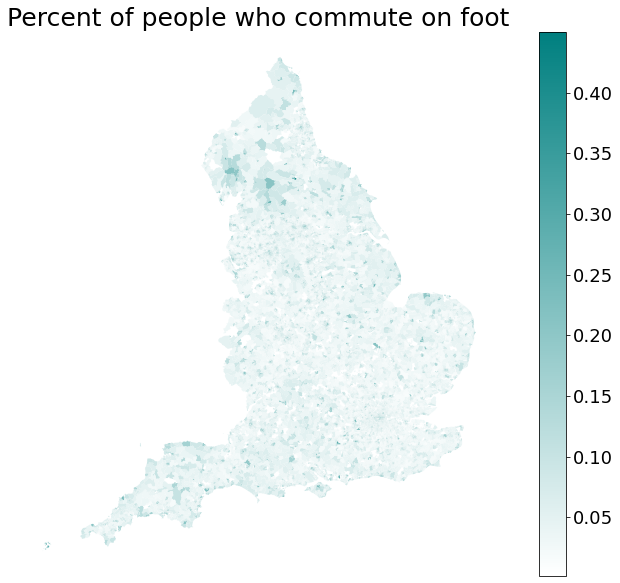

In [15]:
variable =  'c_percent commute on foot'
variable_name = 'Percent of people who commute on foot'
plot_variable(gdf, variable, variable_name)


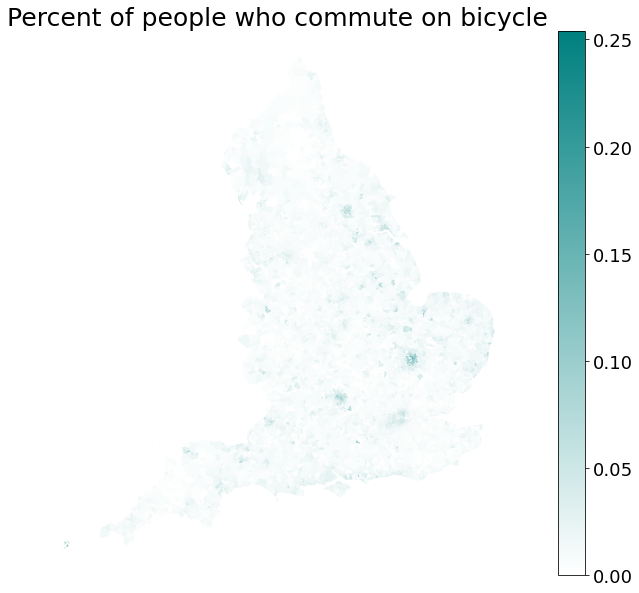

In [16]:
variable =  'c_percent commute bicycle'
variable_name = 'Percent of people who commute on bicycle'
plot_variable(gdf, variable, variable_name)

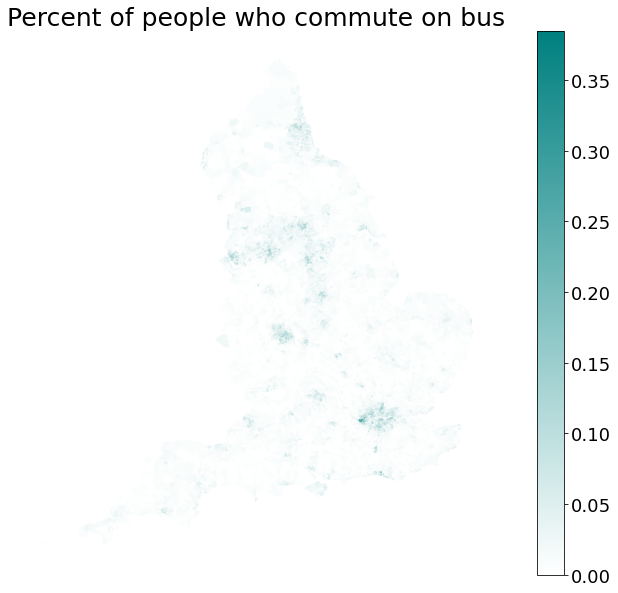

In [17]:
variable =  'c_percent commute bus'
variable_name = 'Percent of people who commute on bus'
plot_variable(gdf, variable, variable_name)

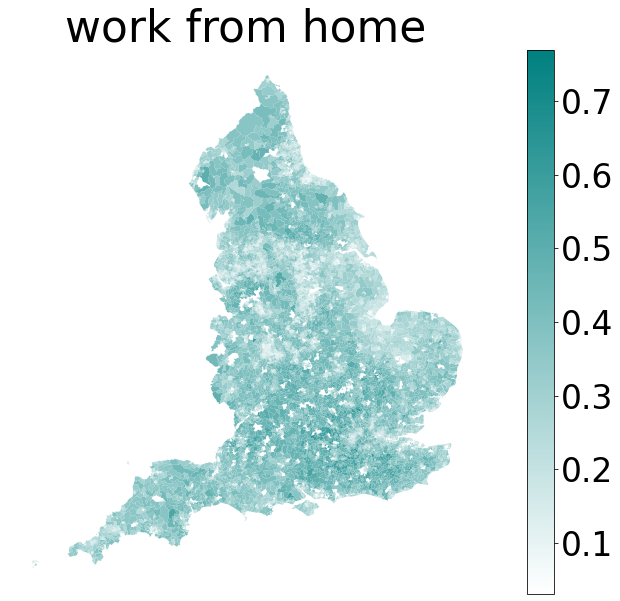

In [82]:
variable =  'c_percent WFH'
variable_name = 'work from home'
plot_variable(gdf, variable, variable_name)

In [50]:
# variable =  'c_net annual income'
# variable_name = 'net annual income'
# plot_variable_v2(gdf, variable, variable_name)

# Environment

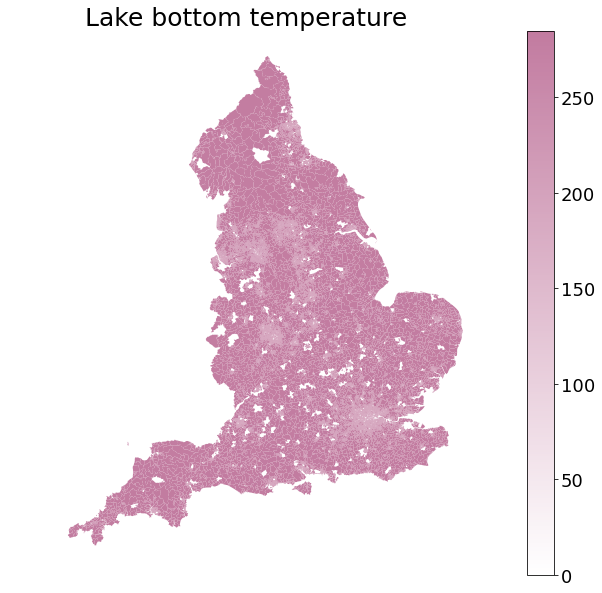

In [19]:
variable =  'e_lake_bottom_temperature'
variable_name = 'Lake bottom temperature'
plot_variable(gdf, variable, variable_name)

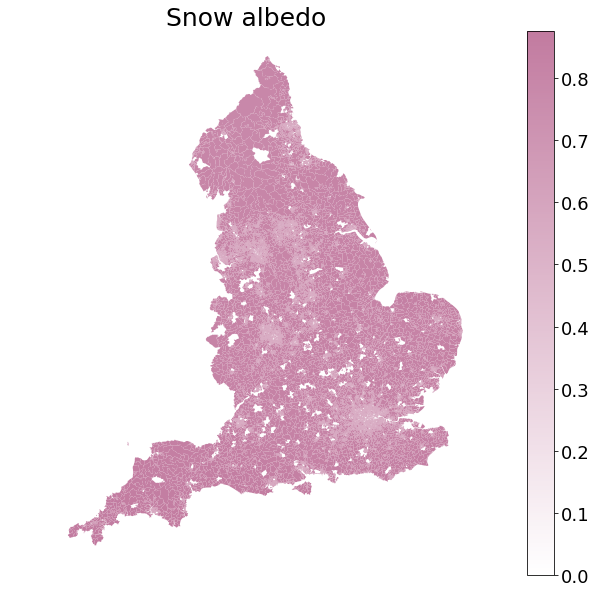

In [20]:
variable =  'e_snow_albedo'
variable_name = 'Snow albedo'
plot_variable(gdf, variable, variable_name)

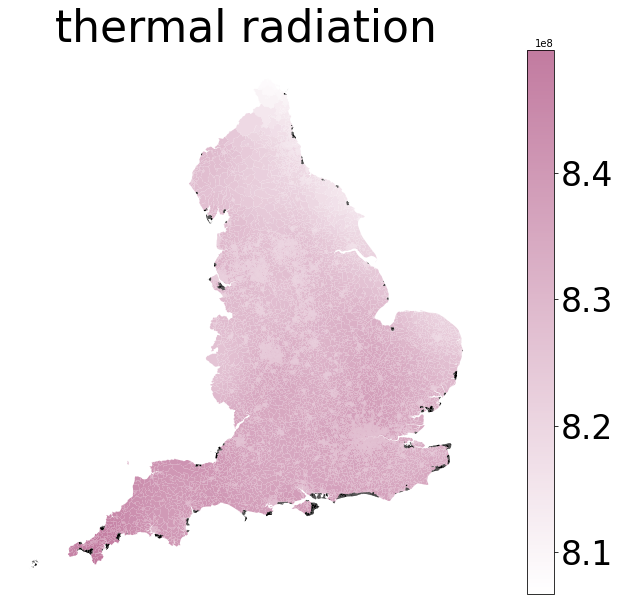

In [96]:
variable =  'e_surface_thermal_radiation_downwards_sum'
variable_name = 'thermal radiation'
plot_variable_v2(gdf, variable, variable_name)

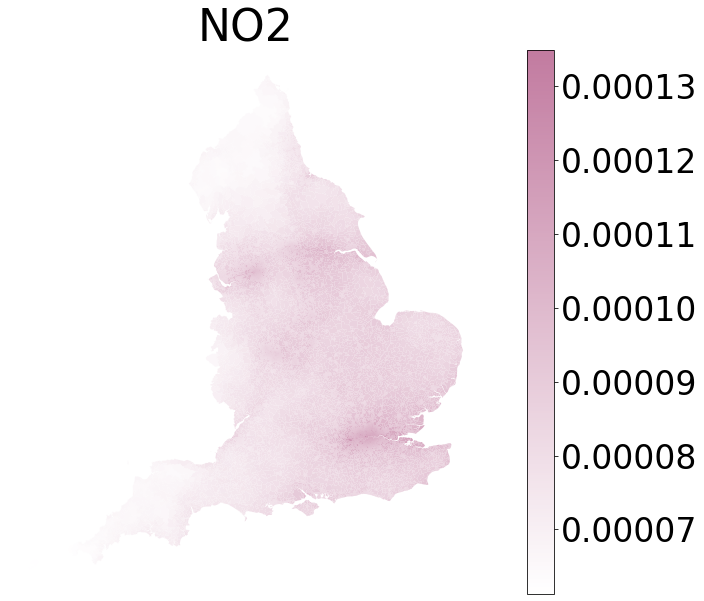

In [93]:
variable =  'e_NO2'
variable_name = 'NO2'
plot_variable_v2(gdf, variable, variable_name)


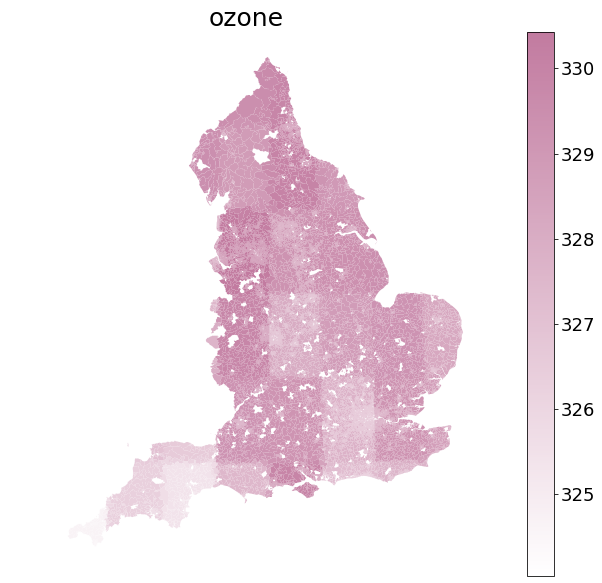

In [23]:
variable =  'e_ozone'
variable_name = 'ozone'
plot_variable(gdf, variable, variable_name)


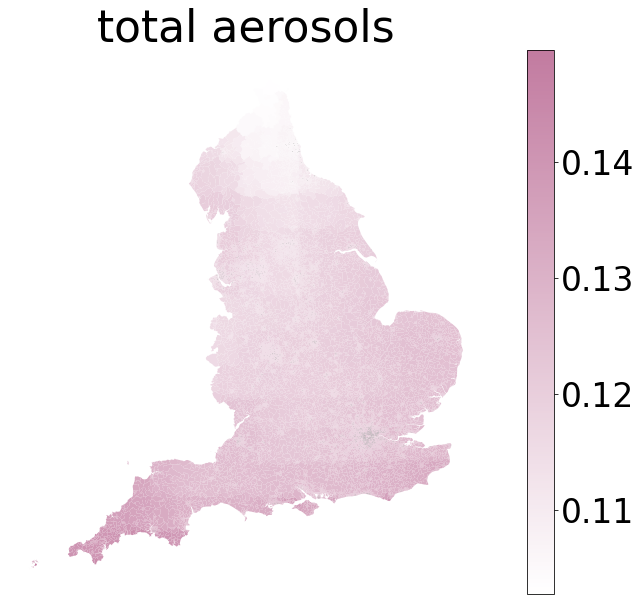

In [89]:
variable =  'e_total_aerosol_optical_depth_at_550nm_surface'
variable_name = 'total aerosols'
plot_variable_v2(gdf, variable, variable_name)


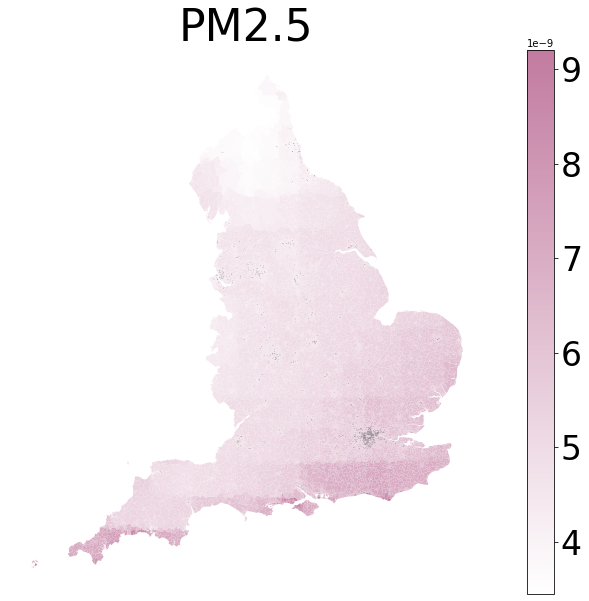

In [74]:
variable =  'e_particulate_matter_d_less_than_25_um_surface'
variable_name = 'PM2.5'
plot_variable_v2(gdf, variable, variable_name)


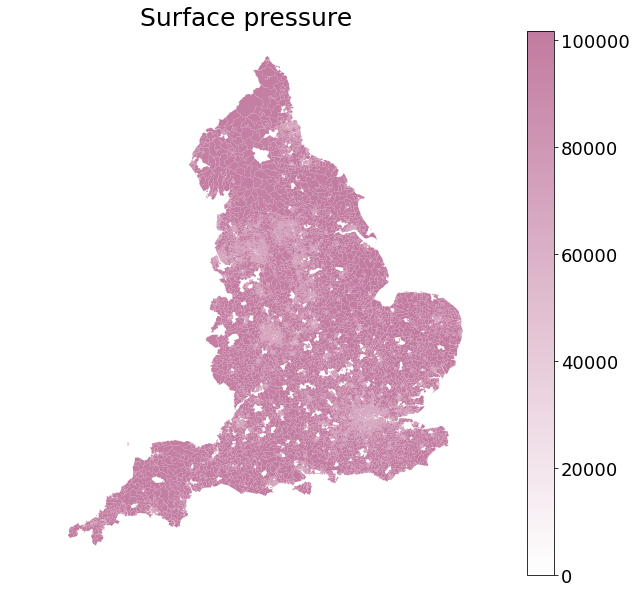

In [26]:
variable =  'e_surface_pressure'
variable_name = 'Surface pressure'
plot_variable(gdf, variable, variable_name)

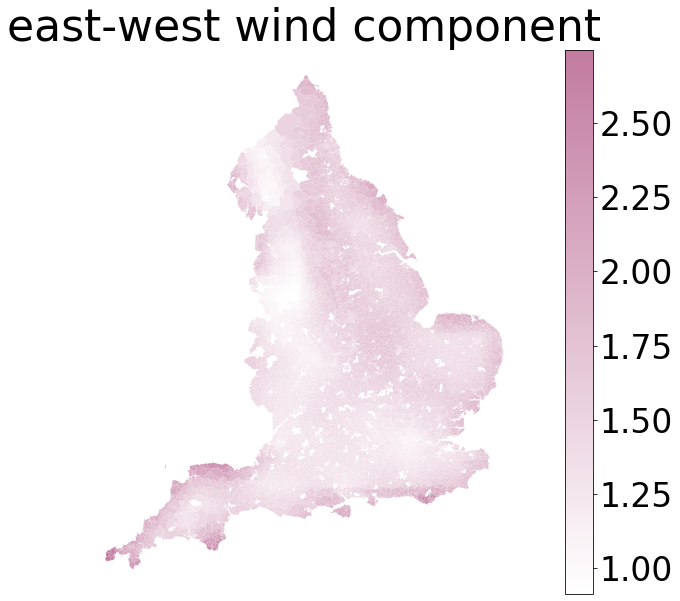

In [18]:
variable =  'e_u_component_of_wind_10m'
variable_name = 'east-west wind component'
plot_variable(gdf, variable, variable_name)

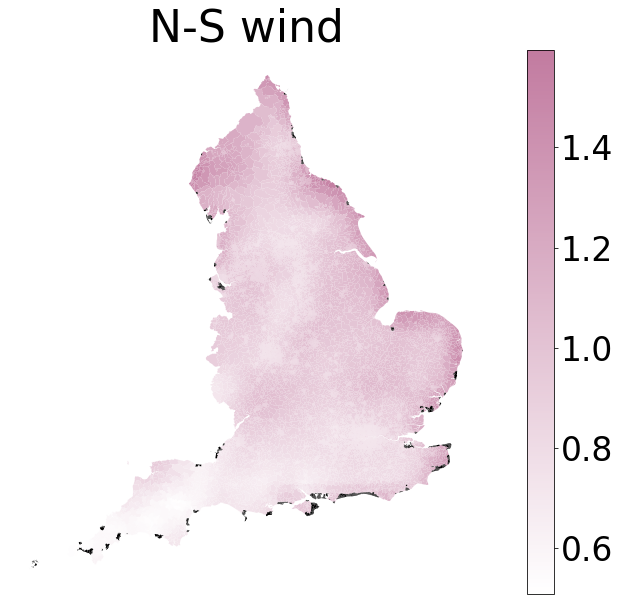

In [97]:
variable =  'e_v_component_of_wind_10m'
variable_name = 'N-S wind'
plot_variable_v2(gdf, variable, variable_name)

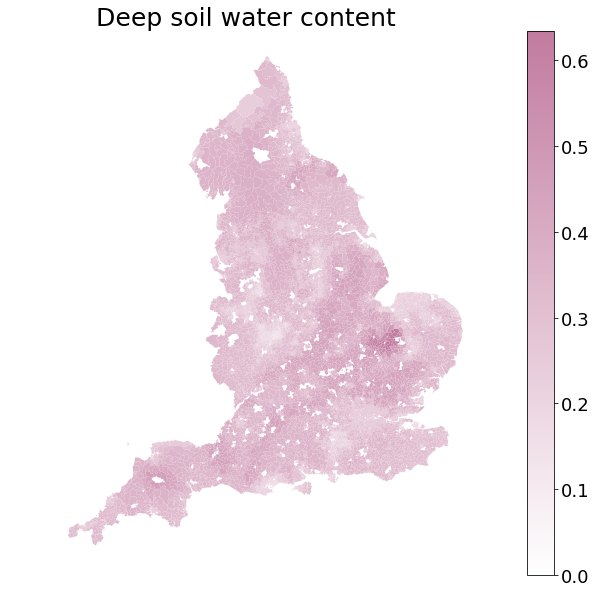

In [29]:
variable =  'e_volumetric_soil_water_layer_3'
variable_name = 'Deep soil water content'
plot_variable(gdf, variable, variable_name)

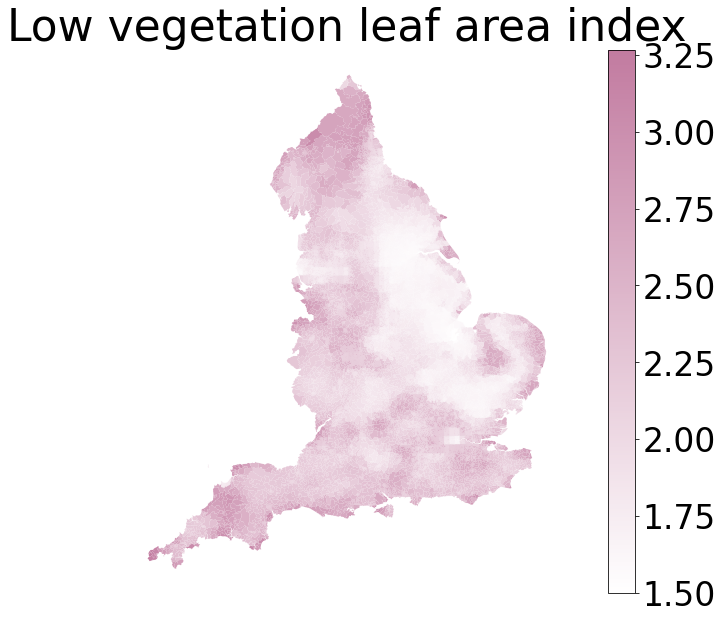

In [76]:
variable =  'e_leaf_area_index_low_vegetation'
variable_name = 'Low vegetation leaf area index'
plot_variable(gdf, variable, variable_name)



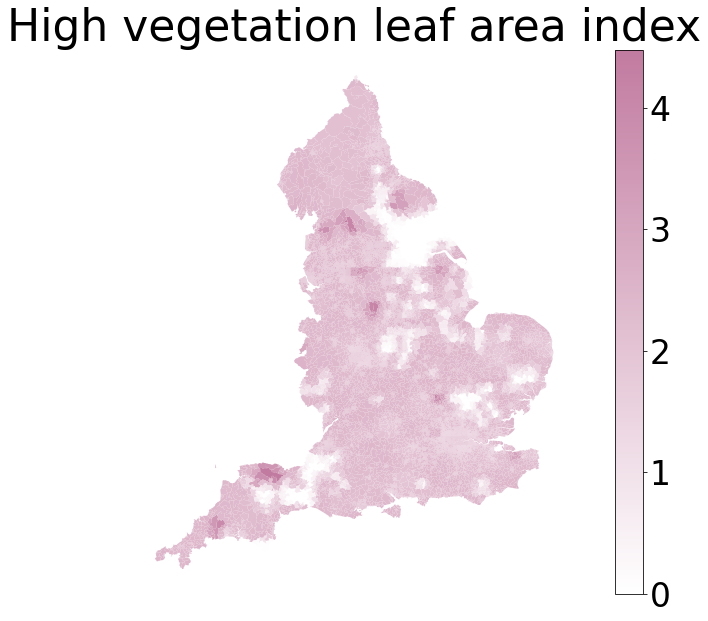

In [77]:
variable =  'e_leaf_area_index_high_vegetation'
variable_name = 'High vegetation leaf area index'
plot_variable(gdf, variable, variable_name)



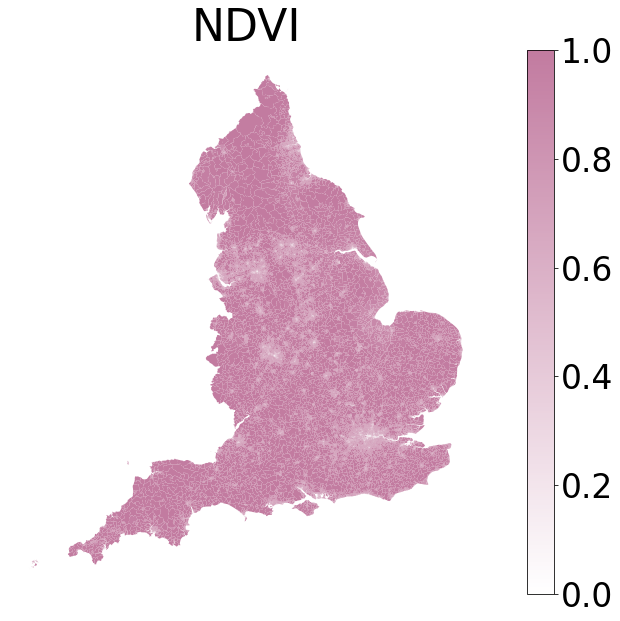

In [78]:
variable =  'e_ndvi'
variable_name = 'NDVI'
plot_variable_v2(gdf, variable, variable_name)

# Outcomes

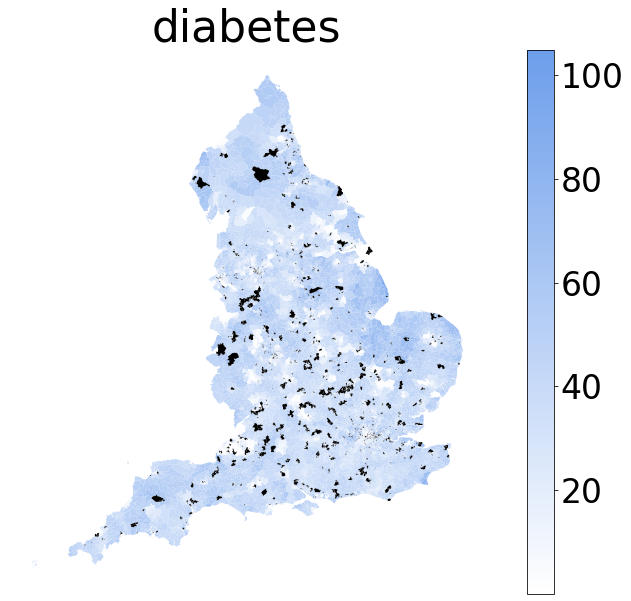

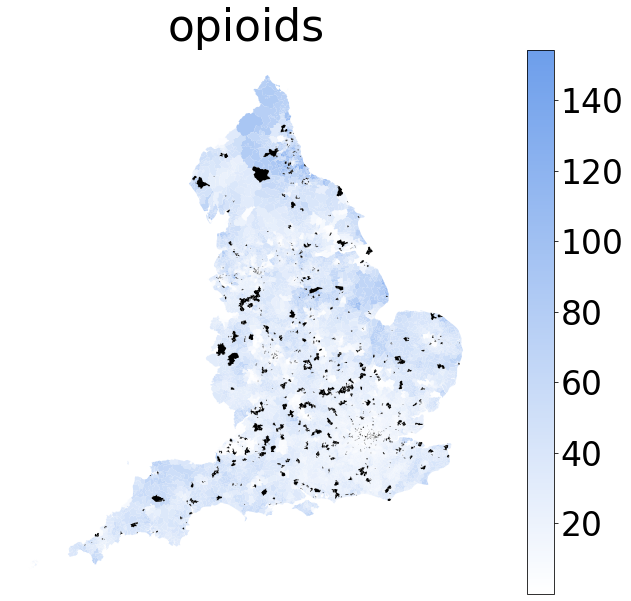

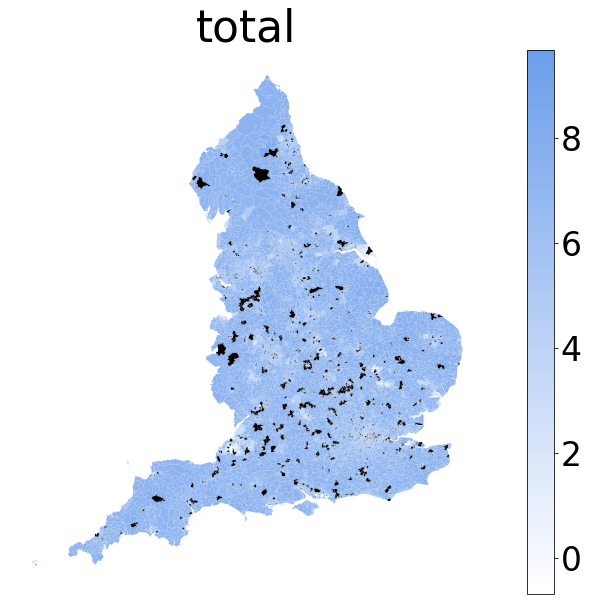

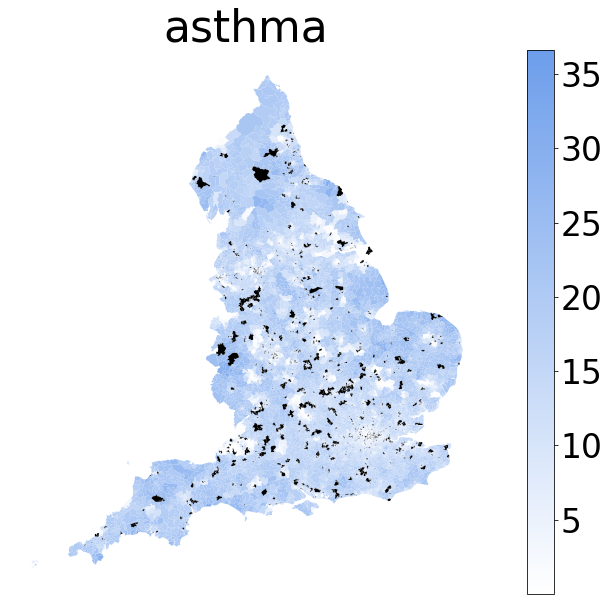

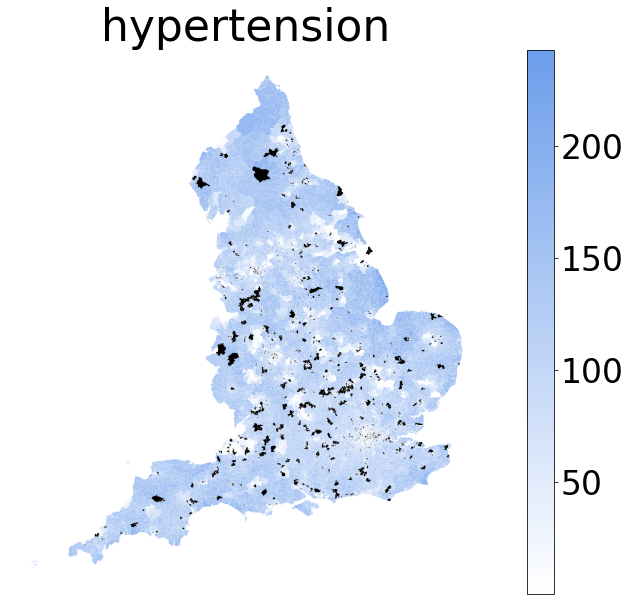

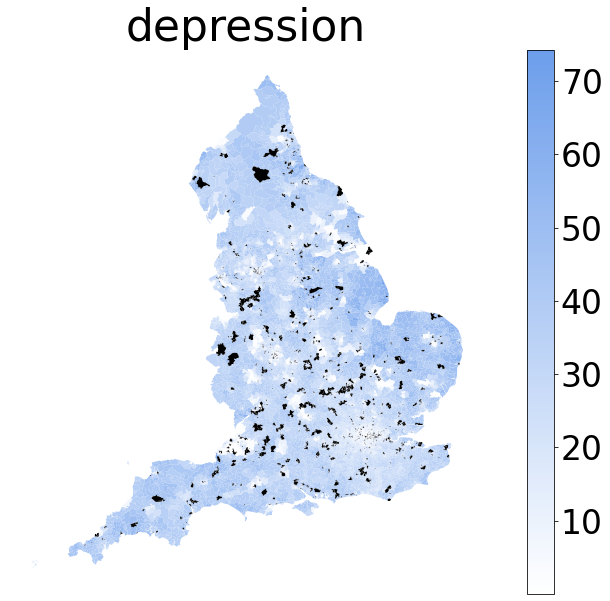

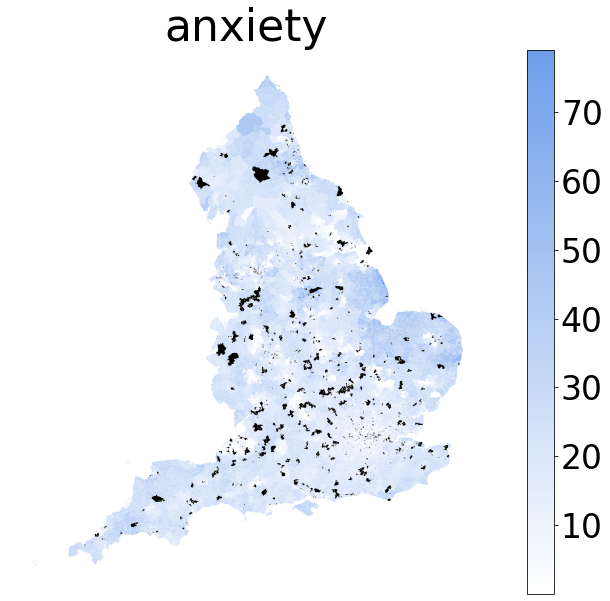

In [98]:
for c in [c for c in gdf.columns if c.startswith('o_') and 'OME' not in c]:
    variable = c
    variable_name = c.replace('o_', '').replace('_quantity_per_capita', '')
    plot_variable_v2(gdf, variable, variable_name)